In [19]:
import rasterio
import numpy as np
from pathlib import Path
from rasterio.merge import merge
from dem_stitcher.merge import merge_arrays_with_geometadata
import matplotlib.pyplot as plt

In [23]:
vv_paths = sorted(list(Path('los-angeles/11SLT/71/2023-12-22').glob('*VV.tif')))
vv_paths[:3]

[PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151226-IW2_20231222T135254Z_20231223T205846Z_S1A_30_v1.0_VV.tif'),
 PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151226-IW3_20231222T135255Z_20231223T214349Z_S1A_30_v1.0_VV.tif'),
 PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151227-IW2_20231222T135256Z_20231223T214349Z_S1A_30_v1.0_VV.tif')]

In [24]:
vh_paths = sorted(list(Path('los-angeles/11SLT/71/2023-12-22').glob('*VH.tif')))
vh_paths[:3]

[PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151226-IW2_20231222T135254Z_20231223T205846Z_S1A_30_v1.0_VH.tif'),
 PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151226-IW3_20231222T135255Z_20231223T214349Z_S1A_30_v1.0_VH.tif'),
 PosixPath('los-angeles/11SLT/71/2023-12-22/OPERA_L2_RTC-S1_T071-151227-IW2_20231222T135256Z_20231223T214349Z_S1A_30_v1.0_VH.tif')]

In [25]:
def merge_rasters(
    files: list[str | Path],
    output_path: str | Path | None = None,
    method: str = "first",
    nodata: float | None = None,
) -> tuple[np.ndarray, dict]:
    src_files = [rasterio.open(f) for f in files]
    
    mosaic, transform = merge(src_files, method=method, nodata=nodata)
    
    p_merged = src_files[0].profile.copy()
    p_merged.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": transform,
    })
    if nodata is not None:
        p_merged["nodata"] = nodata
    
    for src in src_files:
        src.close()
    
    if output_path:
        with rasterio.open(output_path, "w", **p_merged) as dst:
            dst.write(mosaic)
    
    return mosaic, p_merged

In [26]:
arr_vh_m, p_vh_m = merge_rasters(vh_paths)

In [27]:
arr_vv_m, p_vv_m = merge_rasters(vv_paths)

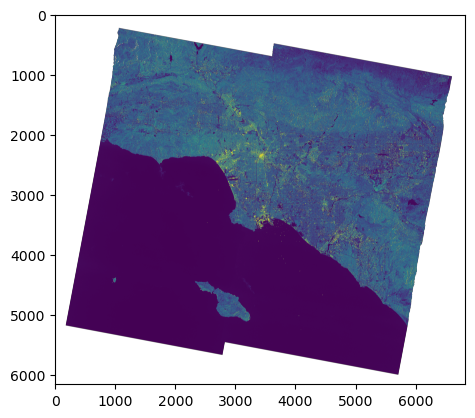

In [29]:
plt.imshow(arr_vh_m[0, ...], vmin=0, vmax=.15)

In [30]:
def vv_vh_to_rgb(vv, vh, vmin_percentile=2, vmax_percentile=98):
    def normalize_band(band):
        vmin = np.nanpercentile(band, vmin_percentile)
        vmax = np.nanpercentile(band, vmax_percentile)
        normalized = np.clip((band - vmin) / (vmax - vmin), 0, None)
        return np.sqrt(normalized)
    
    r = normalize_band(vv)
    g = normalize_band(vh)
    b = normalize_band(vv / vh)
    
    return np.dstack([r, g, b])

/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_7704/4093458784.py:10: RuntimeWarning: divide by zero encountered in divide
  b = normalize_band(vv / vh)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1896.1344].


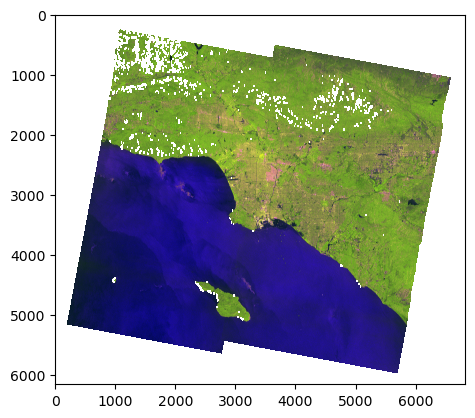

In [31]:
rgb = vv_vh_to_rgb(arr_vv_m[0, ...], arr_vh_m[0, ...])
plt.imshow(rgb)